# True Forward Modeling of TEM
### Direct translation of SimPEG tutorial for forward modeling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps

NumPy version: 2.2.6
Pandas version: 2.3.3
Matplotlib version: 3.10.8


First let's make sure everything is working!!!

✅ Imports successful
NumPy test: [ 0.   2.5  5.   7.5 10. ]


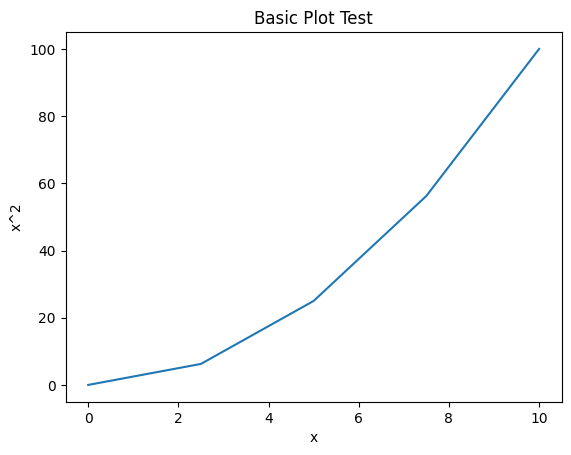

✅ Plotting works
✅ Forward model computed
First 5 values: [2.91752301e-09 1.75953232e-09 1.04873557e-09 6.20230162e-10
 3.66542545e-10]


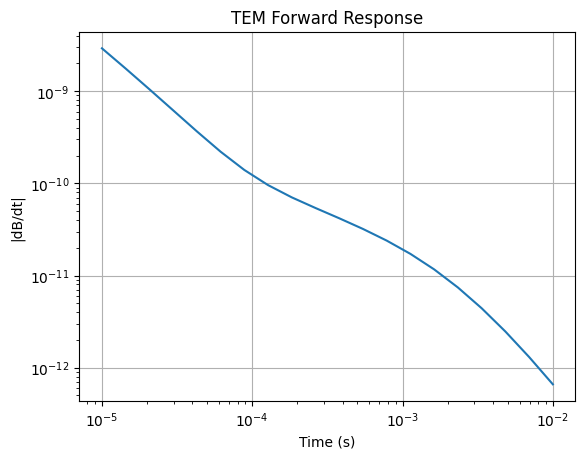

🎉 EVERYTHING IS WORKING


In [ ]:
# ==============================
# ENVIRONMENT + FORWARD MODEL TEST
# ==============================

print("✅ Imports successful")

# ------------------------------
# 1. Basic array + math test
# ------------------------------
x = np.linspace(0, 10, 5)
print("NumPy test:", x)

# ------------------------------
# 2. Simple plot test
# ------------------------------
plt.figure()
plt.plot(x, x**2)
plt.title("Basic Plot Test")
plt.xlabel("x")
plt.ylabel("x^2")
plt.show()

print("✅ Plotting works")

# ------------------------------
# 3. TEM forward model test
# ------------------------------

# Conductivity model (S/m)
sigma = np.array([0.1, 1.0, 0.1])  # 3 layers

# Layer thicknesses (m)
thicknesses = np.array([40.0, 40.0])

# Time channels (seconds)
times = np.logspace(-5, -2, 20)

# Receiver
rx = tdem.receivers.PointMagneticFluxDensity(
    locations=np.array([[0, 0, 0]]),
    times=times,
    orientation="z",
)

# Source (circular loop)
src = tdem.sources.CircularLoop(
    receiver_list=[rx],
    location=np.array([0, 0, 0]),
    radius=10.0,
    current=1.0,
)

# Survey
survey = tdem.Survey([src])

# Simulation
sim = tdem.Simulation1DLayered(
    survey=survey,
    thicknesses=thicknesses,
    sigmaMap=maps.IdentityMap(nP=3),
)

# Forward model
dpred = sim.dpred(sigma)

print("✅ Forward model computed")
print("First 5 values:", dpred[:5])

# ------------------------------
# 4. Plot TEM response
# ------------------------------
plt.figure()
plt.loglog(times, np.abs(dpred))
plt.xlabel("Time (s)")
plt.ylabel("|dB/dt|")
plt.title("TEM Forward Response")
plt.grid(True)
plt.show()

print("🎉 EVERYTHING IS WORKING")

#### Start with water content (theta) and conver to electrical conductivity (sigma)

#### Define conductivity vs depth

In [1]:
import numpy as np

# Conductivity model (S/m)
sigma = np.array([0.1, 1.0, 0.1])   # 3 layers

# Thicknesses (m)
thicknesses = np.array([40.0, 40.0])

#### Define surver (source+reciever+times)

In [2]:
import simpeg.electromagnetics.time_domain as tdem

# time channels (seconds)
times = np.logspace(-5, -2, 20)

# receiver
receiver = tdem.receivers.PointMagneticFluxDensity(
    locations=np.array([[0, 0, 0]]),
    times=times,
    orientation="z",
)

# source (loop)
source = tdem.sources.CircularLoop(
    receiver_list=[receiver],
    location=np.array([0, 0, 0]),
    radius=10.0,
    current=1.0,
)

survey = tdem.Survey([source])

#### Define simulation and compute response

In [3]:
from simpeg import maps

# identity map (model = conductivity directly)
sigma_map = maps.IdentityMap(nP=len(sigma))

simulation = tdem.Simulation1DLayered(
    survey=survey,
    thicknesses=thicknesses,
    sigmaMap=sigma_map,
)

# forward model
dpred = simulation.dpred(sigma)

#### Plot result

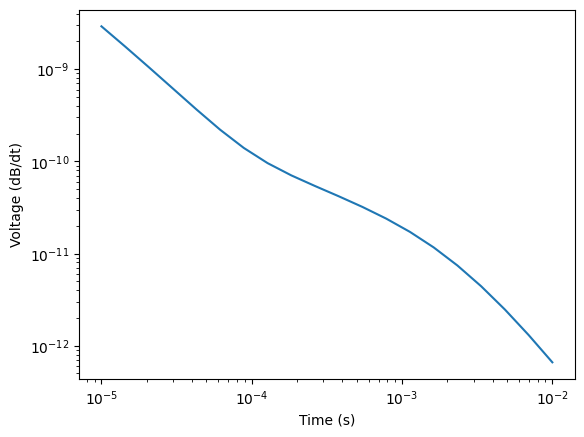

In [4]:
import matplotlib.pyplot as plt

plt.loglog(times, dpred)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (dB/dt)")
plt.show()

Produces the synthetic TEM signal produced by a known layered conductivity model using SimPEG [Produced using ChatGPT]

In [ ]:
import numpy as np
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps

# simple conductivity model
sigma = np.array([0.1, 1.0, 0.1]) ## electrical conductivity of each layer
thicknesses = np.array([40.0, 40.0]) ## thickness of the top two layers

times = np.logspace(-5, -2, 20)

rx = tdem.receivers.PointMagneticFluxDensity(
    locations=np.array([[0,0,0]]),
    times=times,
    orientation="z",
)

src = tdem.sources.CircularLoop(
    receiver_list=[rx],
    location=np.array([0,0,0]),
    radius=10,
    current=1.0,
)

survey = tdem.Survey([src])

sim = tdem.Simulation1DLayered(
    survey=survey,
    thicknesses=thicknesses,
    sigmaMap=maps.IdentityMap(nP=3),
)

dpred = sim.dpred(sigma) ## gives the synthetic TEM response i.e. Prediction of observations

## print(dpred[:5])

[2.91752301e-09 1.75953232e-09 1.04873557e-09 6.20230162e-10
 3.66542545e-10]
